# Minizinc Solver Runner

## Imports

In [ ]:
import sys

sys.path.append("../data-structure")
from instance_data import InstanceData
sys.path.append("..")
import scheduler_plot


## Minizinc Data Preparation

In [20]:
class ZincInstanceData:
    """ZincInstanceData is a class that loads the instance data from a JSON file and provides access to the data."""

    _n: int = 0
    _m: int = 0
    _horizon: int = 0
    _capable: list[list[int]] = []
    _duration: list[list[int]] = []
    _release: list[list[int]] = []
    _setup: list[list[list[int]]] = []

    def __init__(self, raw_instance: InstanceData):
        self.raw_instance = raw_instance
        self._n = raw_instance.json_data["n"]
        self._m = raw_instance.json_data["m"]
        self._horizon = raw_instance.json_data["horizon"]
        self._capable = raw_instance.json_data["capable"]
        self._duration = raw_instance.json_data["duration"]
        self._release = raw_instance.json_data["release"]
        self._setup = raw_instance.json_data["setup"]

    def to_dzn(self) -> str:
        """Convert the instance data to a string in the format of a .dzn file."""

        duration_flattened = [item for sublist in self._duration for item in sublist]
        release_flattened = [item for sublist in self._release for item in sublist]
        setup_flattened = [item for sublist in self._setup for innerlist in sublist for item in innerlist]

        dzn_str = f"n = {self._n};\n"
        dzn_str += f"m = {self._m};\n"
        dzn_str += f"horizon = {self._horizon};\n"
        dzn_str += f"capable = {[set(n) for n in self._capable]};\n"
        dzn_str += f"duration = array2d(1..n, 0..m-1, [{', '.join(str(d) for d in duration_flattened)}]);\n"
        dzn_str += f"release = array2d(1..n, 0..m-1, [{', '.join(str(r) for r in release_flattened)}]);\n"
        dzn_str += f"setup = array3d(1..n, 1..n, 0..m-1, [{', '.join(str(s) for s in setup_flattened)}]);\n"
        return dzn_str

## Main execution

In [21]:
def setup(path: str = "../examples/75_3_5_H.json") -> ZincInstanceData:
    """Setup the instance data for the model."""
    raw_instance = InstanceData(path)
    zinc_instance = ZincInstanceData(raw_instance)
    return zinc_instance


def run():
    file = "../examples/357_15_146_H.json"
    data = setup(file)
    data_dzn = data.to_dzn()
    with open("instance_data.dzn", "w") as f:
        f.write(data_dzn)
    print("Instance data loaded and saved to .dzn format")

run()

Instance data loaded and saved to .dzn format


## Important note

This file is here to help run the model and generate the related dzn file. It is not meant to run the model as it is very memory hungry and can easily crash the system if not used with caution.

In order to run the model, we recommend using Minizinc IDE and setup the solver such as :
- Solver: OR-Tools
- Optimization level: O5
- Number of threads: we used 4 however this can be changed depending on the system capabilities.

The best result we got for the instance 357_15_146_H can be found in the best.json file. This result was obtained after running the model for 2 hours with the above mentioned settings. Due to time constraint we had to kill the process after 2 hours. For a better result we recommend running the model for a long time to get good results as the model is very complex and can take a long time to solve.

The model is cpu hungry and can easily crash the system if not used with caution. We recommend running the model on a powerful machine with nothing else running in the background to get good results. We also recommend running the model on a machine with at least 16GB of RAM to avoid crashing the system.

The runs were made on a intel core i7-11390H with 16GB of RAM. The results may vary depending on the system capabilities and the settings used for the solver.

For more information about the model please refer to the comments found in it.

# Plot best case found

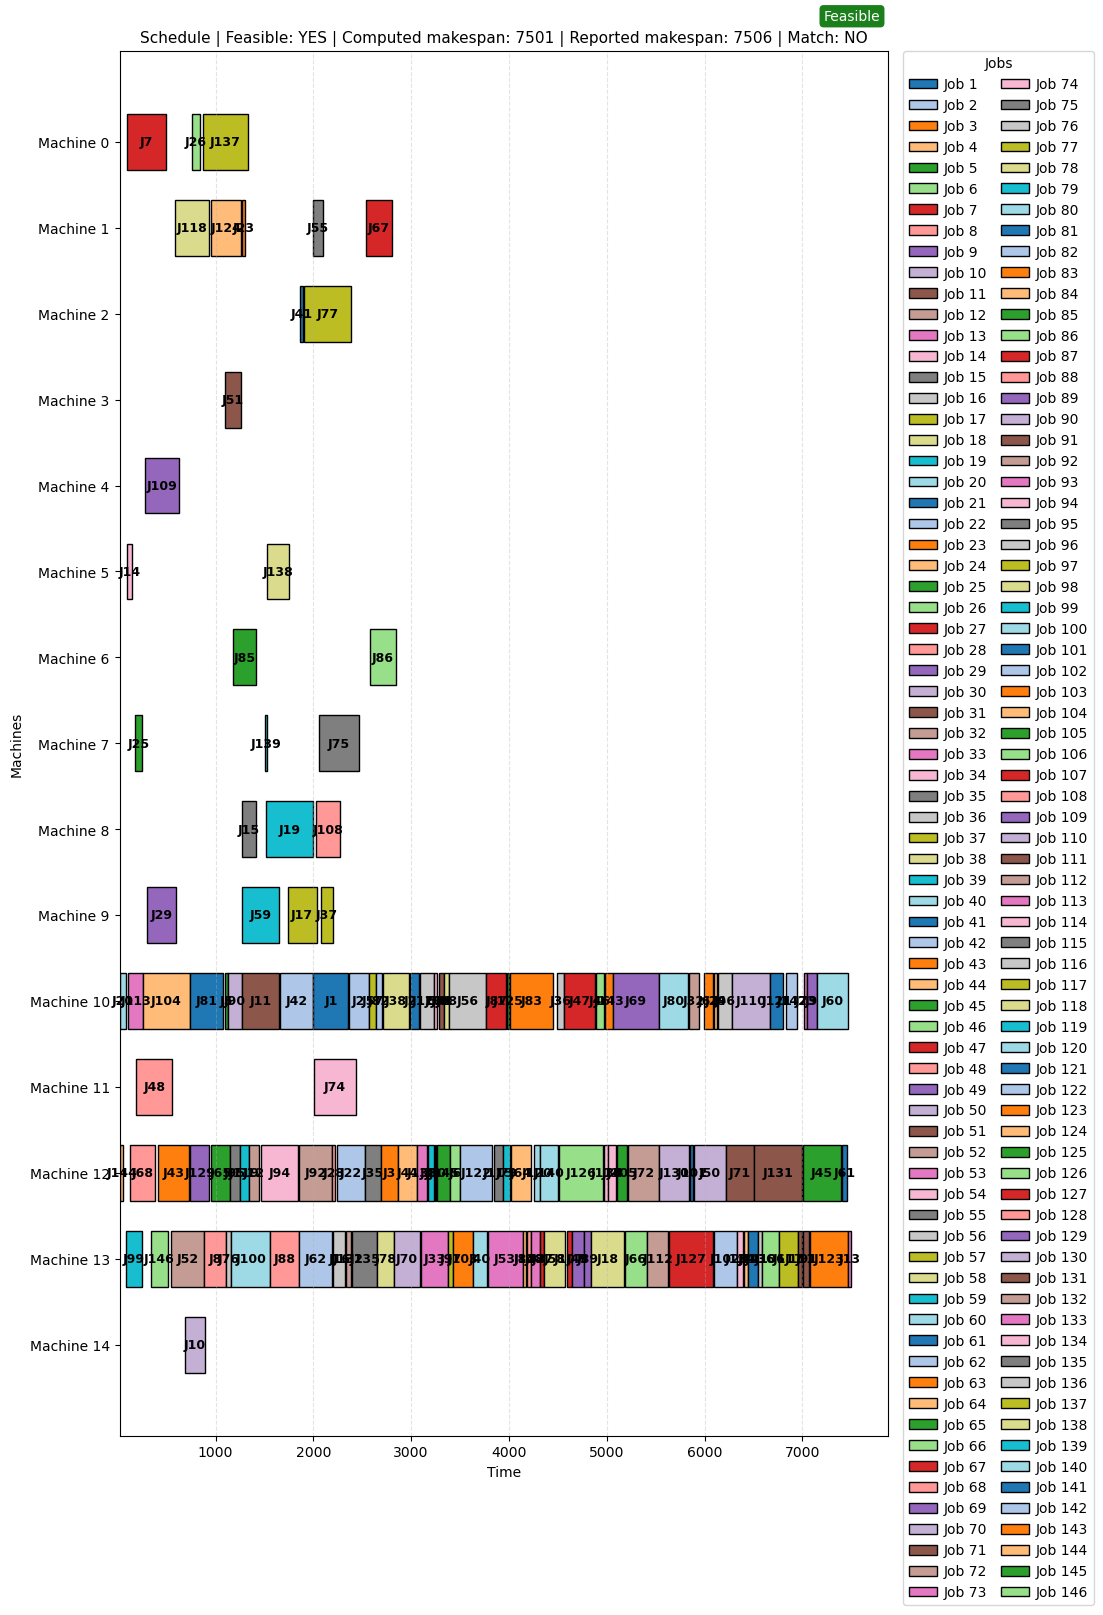

{'feasible': True,
 'checker_result': 7501,
 'reported_makespan': 7506,
 'computed_makespan': 7501}

In [22]:
scheduler_plot.plot_schedule_from_json("../examples/357_15_146_H.json", "best.json")
